 # House Price EDA — King County Dataset
 > Explore the data before building any model.

 Run cell-by-cell in Jupyter/VSCode, or as a full script.

 ## 1. Setup & Load Data

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display settings
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/raw/kc_house_data.csv')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset: 21,613 rows × 21 columns


 ## 2. First Look — Shape, Types, Sample

In [18]:
print("=== DATA TYPES ===")
print(df.dtypes)
print(f"\n=== FIRST 3 ROWS ===")
df.head(3)

=== DATA TYPES ===
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

=== FIRST 3 ROWS ===


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221,900.00",3,1.00,1180,5650,1.00,0,0,3,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,"538,000.00",3,2.25,2570,7242,2.00,0,0,3,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,"180,000.00",2,1.00,770,10000,1.00,0,0,3,6,770,0,1933,0,98028,47.74,-122.23,2720,8062


In [19]:
print("=== BASIC STATISTICS ===")
df.describe()

=== BASIC STATISTICS ===


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,301,520.86","540,088.14",3.37,2.11,"2,079.90","15,106.97",1.49,0.01,0.23,3.41,7.66,"1,788.39",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
std,"2,876,565,571.31","367,127.20",0.93,0.77,918.44,"41,420.51",0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"
min,"1,000,102.00","75,000.00",0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00","321,950.00",3.00,1.75,"1,427.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00","450,000.00",3.00,2.25,"1,910.00","7,618.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00","645,000.00",4.00,2.50,"2,550.00","10,688.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00","7,700,000.00",33.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"


 ## 3. Missing Values

In [20]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]

if len(missing_df) == 0:
    print("No missing values — clean dataset.")
else:
    print("=== MISSING VALUES ===")
    print(missing_df.sort_values('count', ascending=False))

No missing values — clean dataset.


 ## 4. Target Variable — Price Distribution

 **Key question:** Is price normally distributed or skewed?

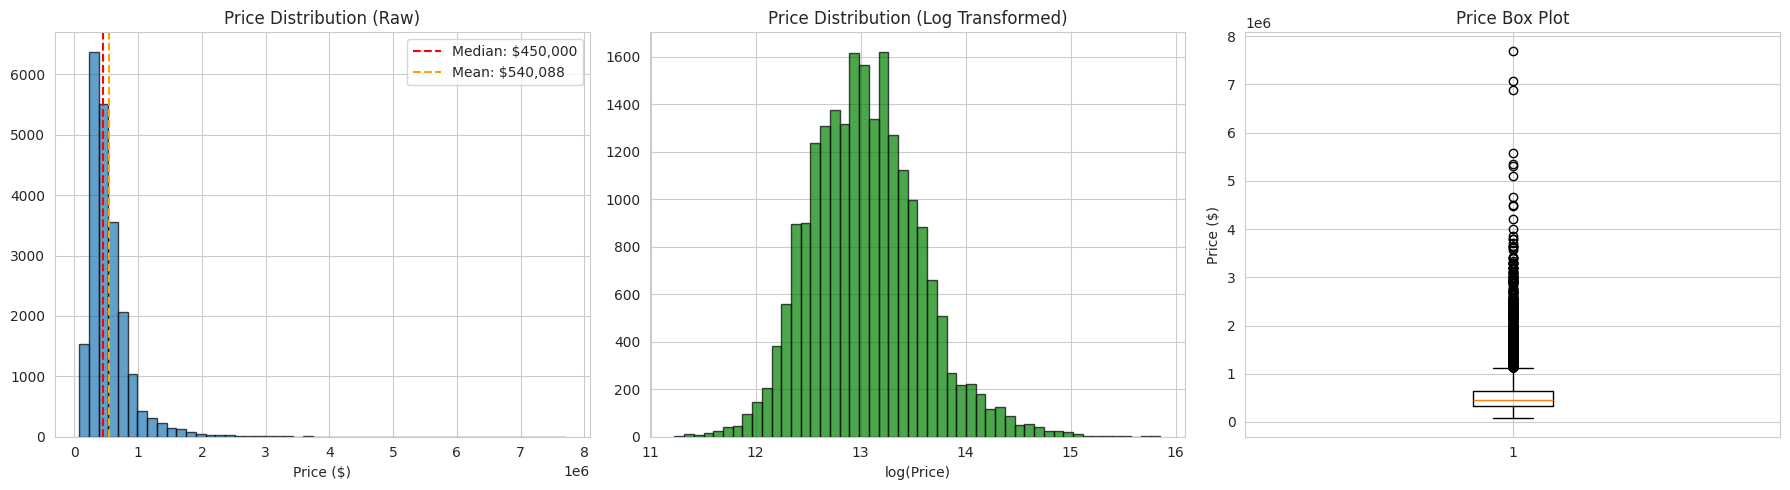


Price Summary:
  Min:    $      75,000
  25th:   $     321,950
  Median: $     450,000
  75th:   $     645,000
  Max:    $   7,700,000
  Skew:           4.02  ← Right-skewed (consider log transform)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price ($)')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f"Median: ${df['price'].median():,.0f}")
axes[0].axvline(df['price'].mean(), color='orange', linestyle='--', label=f"Mean: ${df['price'].mean():,.0f}")
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')

# Box plot
axes[2].boxplot(df['price'], vert=True)
axes[2].set_title('Price Box Plot')
axes[2].set_ylabel('Price ($)')

plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPrice Summary:")
print(f"  Min:    ${df['price'].min():>12,.0f}")
print(f"  25th:   ${df['price'].quantile(0.25):>12,.0f}")
print(f"  Median: ${df['price'].median():>12,.0f}")
print(f"  75th:   ${df['price'].quantile(0.75):>12,.0f}")
print(f"  Max:    ${df['price'].max():>12,.0f}")
print(f"  Skew:   {df['price'].skew():>12.2f}  {'← Right-skewed (consider log transform)' if df['price'].skew() > 1 else ''}")

 ## 5. Feature Correlations with Price

 **Key question:** Which features have the strongest relationship with price?

=== CORRELATIONS WITH PRICE ===
sqft_living      0.70
grade            0.67
sqft_above       0.61
sqft_living15    0.59
bathrooms        0.53
view             0.40
sqft_basement    0.32
bedrooms         0.31
lat              0.31
waterfront       0.27
floors           0.26
yr_renovated     0.13
sqft_lot         0.09
sqft_lot15       0.08
yr_built         0.05
condition        0.04
long             0.02
id              -0.02
zipcode         -0.05


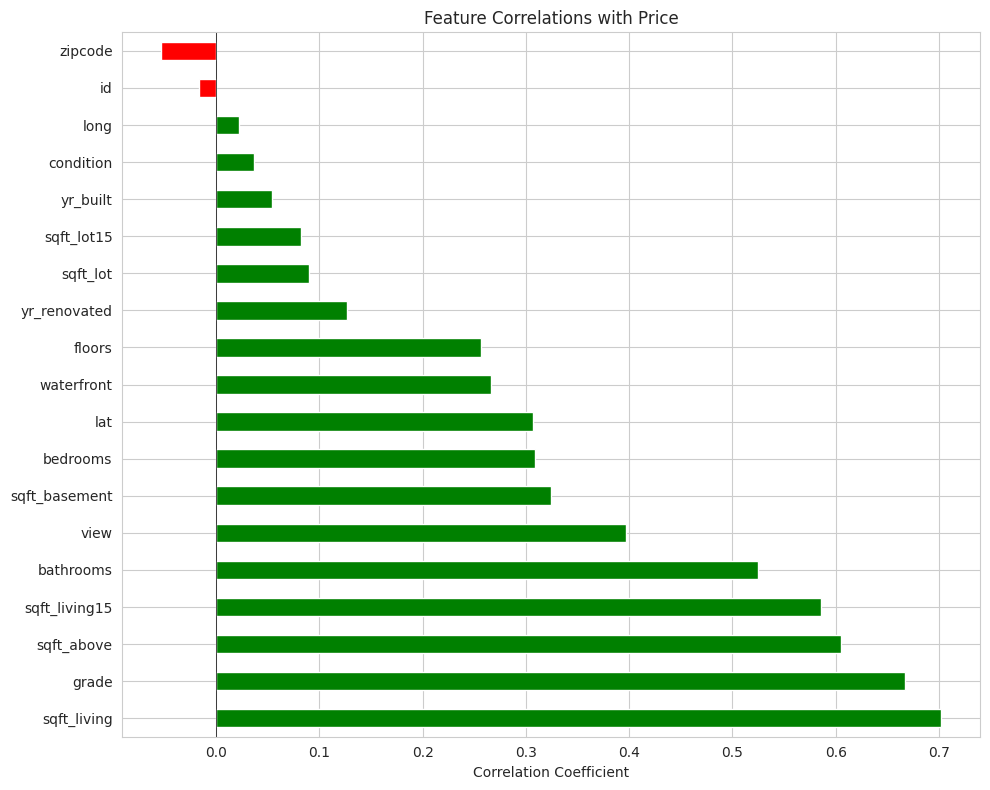

In [22]:
# Correlation with price (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['price'].drop('price').sort_values(ascending=False)

print("=== CORRELATIONS WITH PRICE ===")
print(correlations.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
correlations.plot(kind='barh', ax=ax, color=['green' if x > 0 else 'red' for x in correlations])
ax.set_title('Feature Correlations with Price')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../reports/figures/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

 ## 6. Top Features vs Price — Scatter Plots

 Visualize the strongest predictors.

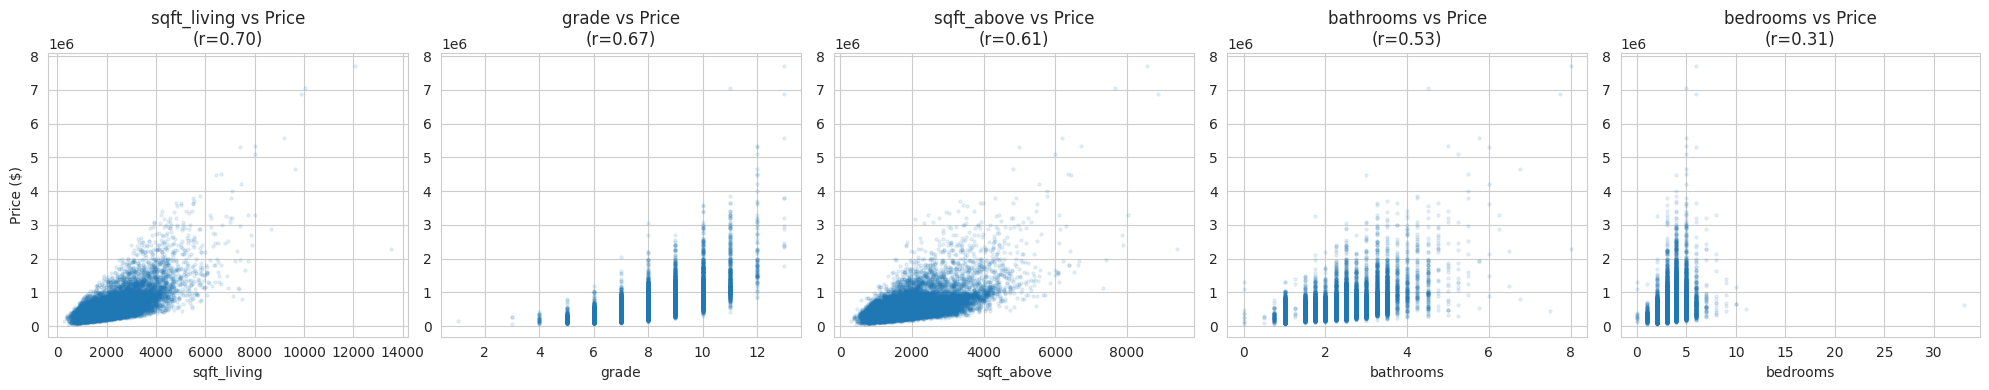

In [23]:
top_features = ['sqft_living', 'grade', 'sqft_above', 'bathrooms', 'bedrooms']

fig, axes = plt.subplots(1, len(top_features), figsize=(20, 4))
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['price'], alpha=0.1, s=5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price ($)' if i == 0 else '')
    axes[i].set_title(f'{feat} vs Price\n(r={df[feat].corr(df["price"]):.2f})')

plt.tight_layout()
plt.savefig('../reports/figures/top_features_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

 ## 7. Categorical/Discrete Features vs Price

 How do discrete groups (grade, condition, floors, waterfront) affect price?

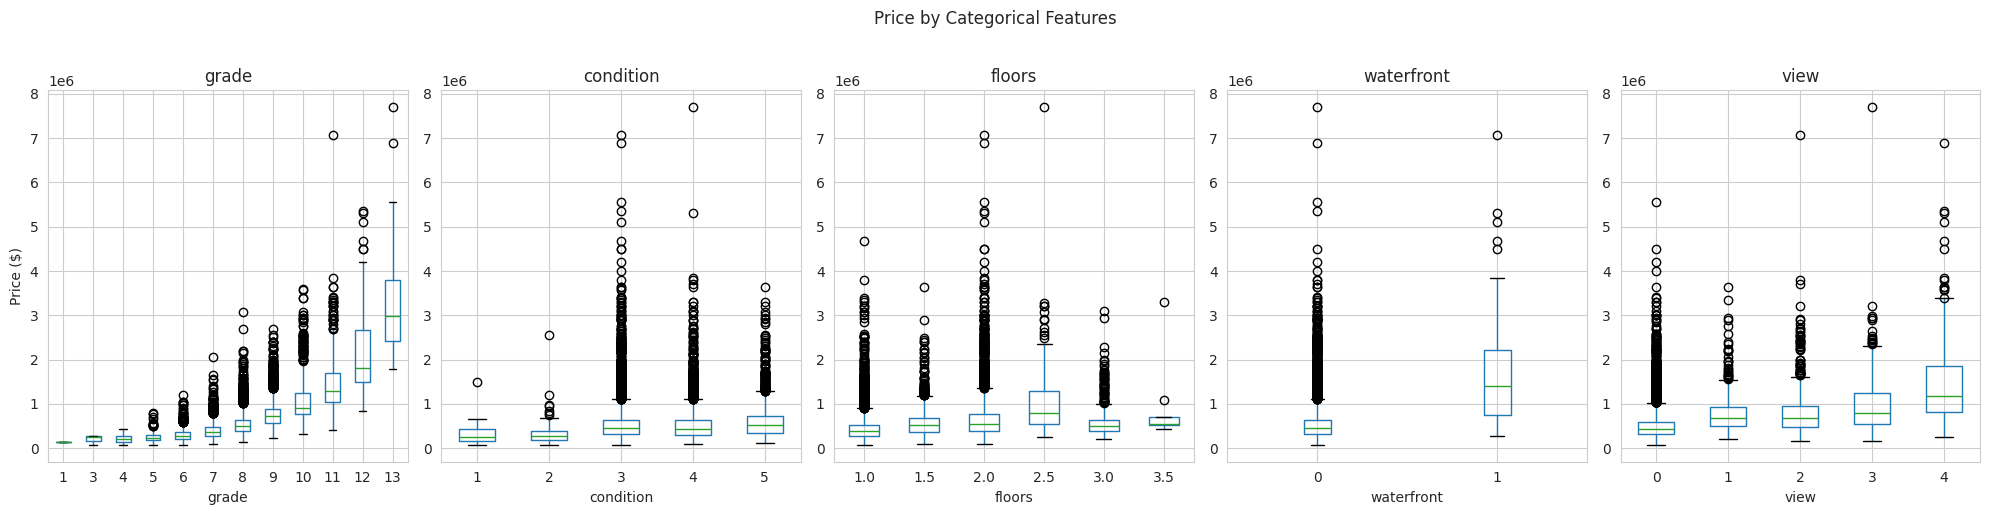

In [24]:
cat_features = ['grade', 'condition', 'floors', 'waterfront', 'view']

fig, axes = plt.subplots(1, len(cat_features), figsize=(20, 5))
for i, feat in enumerate(cat_features):
    df.boxplot(column='price', by=feat, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price ($)' if i == 0 else '')

plt.suptitle('Price by Categorical Features', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/categorical_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

 ## 8. Outlier Detection

 **Key question:** Are there suspicious or extreme values?

In [26]:
print("=== POTENTIAL OUTLIERS ===\n")

# Bedrooms
print(f"Bedrooms distribution:")
print(df['bedrooms'].value_counts().sort_index().to_string())
suspicious_beds = df[df['bedrooms'] > 10]
if len(suspicious_beds) > 0:
    print(f"\n⚠ {len(suspicious_beds)} houses with >10 bedrooms:")
    print(suspicious_beds[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'grade']].to_string())

# Price extremes
print(f"\n\nTop 10 most expensive:")
print(df.nlargest(10, 'price')[['price', 'bedrooms', 'sqft_living', 'grade', 'zipcode']].to_string())

print(f"\n\nBottom 10 cheapest:")
print(df.nsmallest(10, 'price')[['price', 'bedrooms', 'sqft_living', 'grade', 'zipcode']].to_string())

=== POTENTIAL OUTLIERS ===

Bedrooms distribution:
bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1

⚠ 2 houses with >10 bedrooms:
           price  bedrooms  bathrooms  sqft_living  grade
8757  520,000.00        11       3.00         3000      7
15870 640,000.00        33       1.75         1620      7


Top 10 most expensive:
            price  bedrooms  sqft_living  grade  zipcode
7252 7,700,000.00         6        12050     13    98102
3914 7,062,500.00         5        10040     11    98004
9254 6,885,000.00         6         9890     13    98039
4411 5,570,000.00         5         9200     13    98039
1448 5,350,000.00         5         8000     12    98004
1315 5,300,000.00         6         7390     12    98040
1164 5,110,800.00         5         8010     12    98033
8092 4,668,000.00         5         9640     12    98040
2626 4,500,000.00         5         6640     12    981

 ## 9. Geographic Analysis

 **Key question:** Does location drive price?

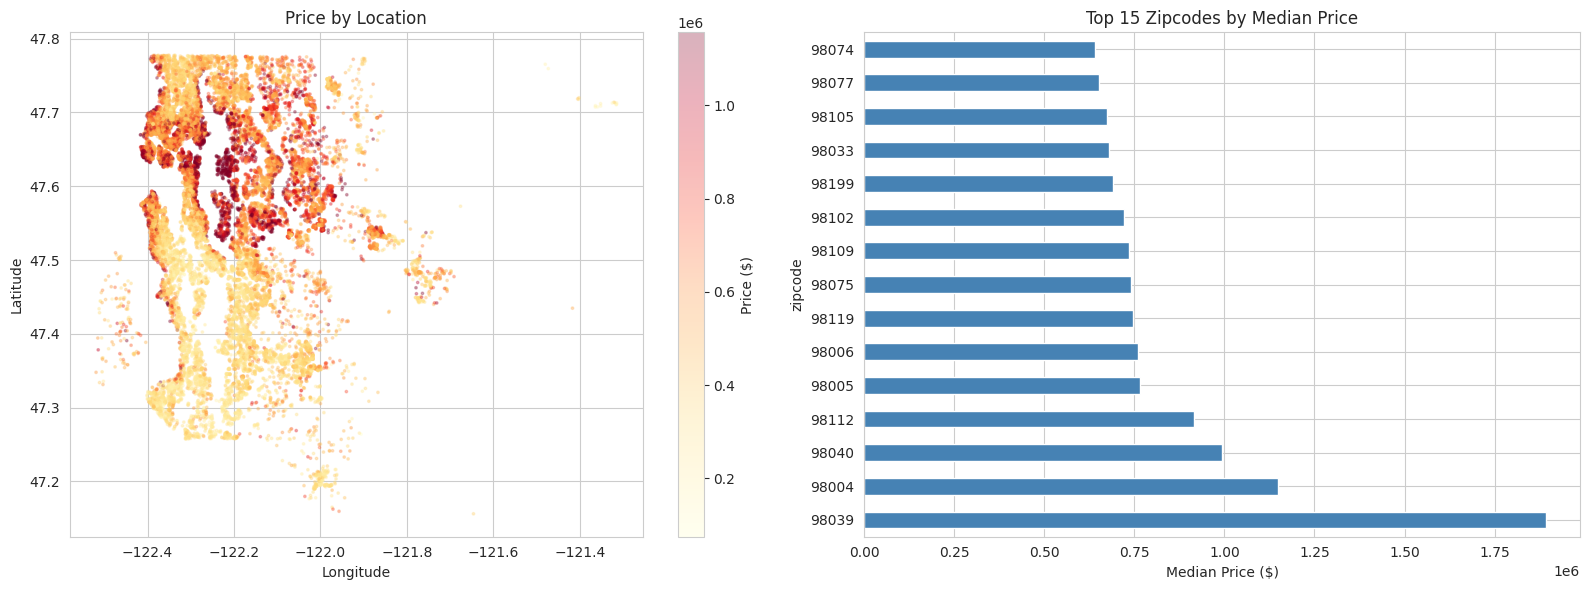


Zipcode price range:
  Most expensive:  98039 — median $1,892,500
  Least expensive: 98168 — median $235,000
  Ratio: 8.1x difference


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price by location (scatter on lat/long)
scatter = axes[0].scatter(df['long'], df['lat'], c=df['price'], cmap='YlOrRd',
                          alpha=0.3, s=3, vmax=df['price'].quantile(0.95))
axes[0].set_title('Price by Location')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(scatter, ax=axes[0], label='Price ($)')

# Median price by zipcode (top 15)
zip_prices = df.groupby('zipcode')['price'].median().sort_values(ascending=False)
zip_prices.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Zipcodes by Median Price')
axes[1].set_xlabel('Median Price ($)')

plt.tight_layout()
plt.savefig('../reports/figures/geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nZipcode price range:")
print(f"  Most expensive:  {zip_prices.index[0]} — median ${zip_prices.iloc[0]:,.0f}")
print(f"  Least expensive: {zip_prices.index[-1]} — median ${zip_prices.iloc[-1]:,.0f}")
print(f"  Ratio: {zip_prices.iloc[0] / zip_prices.iloc[-1]:.1f}x difference")

 ## 10. Feature-to-Feature Relationships

 Are any features redundant (highly correlated with each other)?

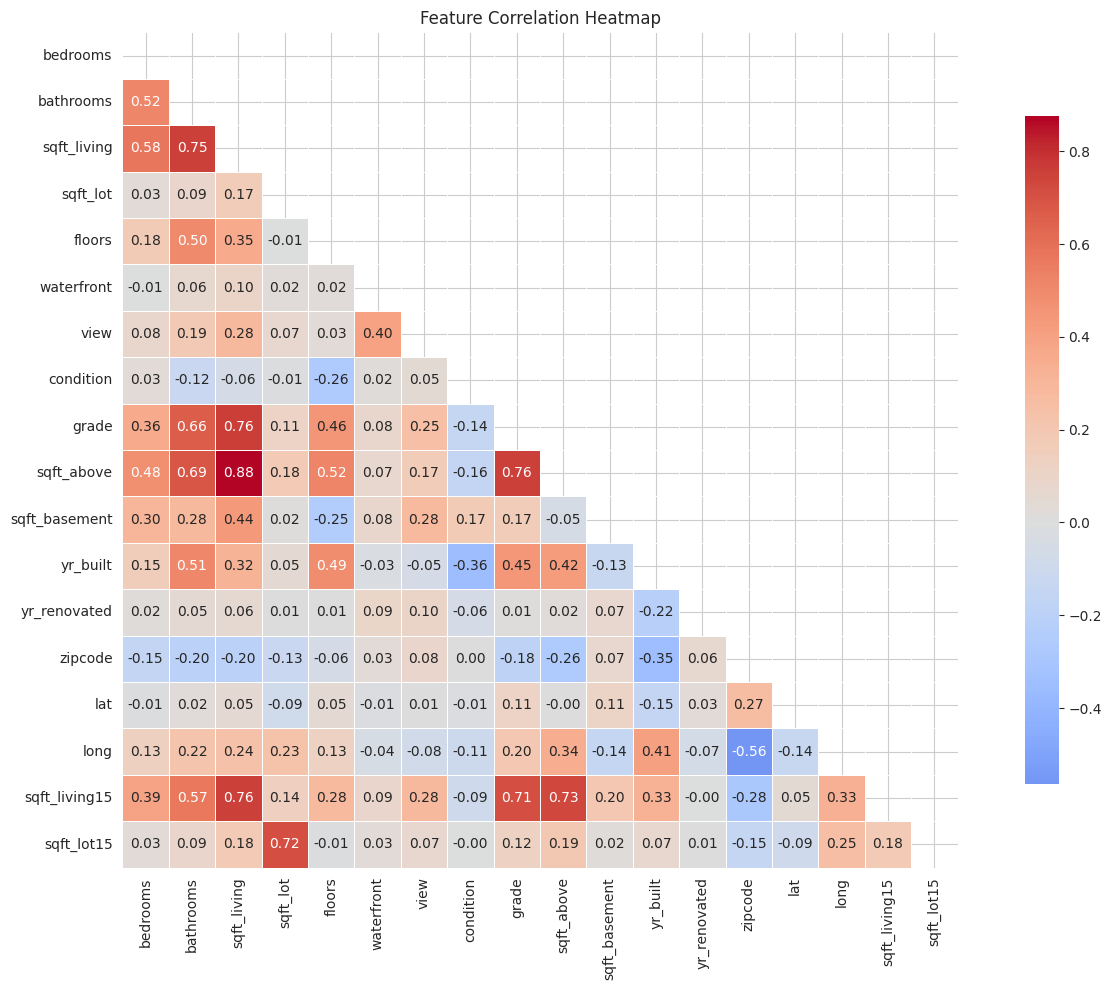

=== HIGHLY CORRELATED PAIRS (|r| > 0.7) ===
  bathrooms            ↔ sqft_living           r=0.75
  sqft_living          ↔ grade                 r=0.76
  sqft_living          ↔ sqft_above            r=0.88
  sqft_living          ↔ sqft_living15         r=0.76
  sqft_lot             ↔ sqft_lot15            r=0.72
  grade                ↔ sqft_above            r=0.76
  grade                ↔ sqft_living15         r=0.71
  sqft_above           ↔ sqft_living15         r=0.73


In [28]:
# Correlation heatmap (numeric features only, exclude id)
cols_for_heatmap = [c for c in numeric_cols if c not in ['id', 'price']]
corr_matrix = df[cols_for_heatmap].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs
print("=== HIGHLY CORRELATED PAIRS (|r| > 0.7) ===")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_matrix.index[i]:20s} ↔ {corr_matrix.columns[j]:20s}  r={r:.2f}")

 ## 11. Summary — Key Findings

 Fill this in after running all cells above:

 | Finding | Detail | Action for Modeling |
 |---------|--------|-------------------|
 | Price is right-skewed | Long tail of expensive homes | Consider log transform |
 | Top predictor: sqft_living | r ≈ 0.70 | Must include |
 | Grade strongly predicts | r ≈ 0.67 | Must include |
 | 33-bedroom outlier | Likely data entry error | Drop or fix |
 | Location matters a lot | Zipcode creates 10x+ price difference | Encode location properly |
 | sqft_above ≈ sqft_living | Highly correlated, redundant | May drop one |
 | yr_built weak alone | Non-linear relationship | May need feature engineering (age) |

 → Take these findings into [04-data-preparation](../04-data-preparation/)